In [1]:
pip install pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 40.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# **Khai báo thư viện**

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Embedding, Dense, Dropout, LSTM, GRU, Input, GlobalMaxPooling1D, GlobalAveragePooling1D, LayerNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras. preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from pyvi import ViTokenizer
from pyvi import ViUtils

2025-05-25 05:18:46.399677: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748150326.631038      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748150326.725330      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#**Đọc và tiền xử lý dữ liệu**

In [3]:
data = pd. read_csv("/kaggle/input/chuyende3/combined_data2.csv")
print("Thống kê bộ dữ liệu: ");
print("Số dòng dữ liệu là: ", data.shape[0])
print("Số cột dữ liệu là: ", data.shape[1])
data.head(10)


Thống kê bộ dữ liệu: 
Số dòng dữ liệu là:  43112
Số cột dữ liệu là:  2


,content,label
0,chất lượng sản phẩm tuyệt vời đóng gói sản phẩ...,pos
1,sản phẩm đẹp đáng tiền,pos
2,được giá tiền nha,pos
3,rảnh mới time đánh giá sh sh cskh nhiệt tình q...,pos
4,giày đẹp giao hàng nhanh mọi người bảo size rộ...,pos
5,tặng nhiệt tình,pos
6,áo len hợp mặc áo khoác không quá dày không qu...,pos
7,cặp đẹp hơn nhiều so mong đợi,pos
8,lại được tặng thêm đôi tất bé bé xinh xinh,pos
9,áo đẹp y hình giao hẹn,pos


In [4]:
print("Thông tin bộ dữ liệu là: ", data.shape)
negative_count = len(data[data['label'] == 'neg'])
print("Số lượng nhãn Negative là:", negative_count)

positive_count = len(data[data['label'] == 'pos'])
print("Số lượng nhãn Positive là:", positive_count)

neutral_count = len(data[data['label'] == 'neu'])
print("Số lượng nhãn Neutral là:", neutral_count)

print("Kiểu dữ liệu của các thuộc tính:\n", data.dtypes )

Thông tin bộ dữ liệu là:  (43112, 2)
Số lượng nhãn Negative là: 14372
Số lượng nhãn Positive là: 14372
Số lượng nhãn Neutral là: 14368
Kiểu dữ liệu của các thuộc tính:
 content    object
label      object
dtype: object


In [5]:
#Xác định lại các thuộc tính trong bộ dữ liệu
sentiment_data = pd.DataFrame({'input':data['content'], 'label':data['label']})
sentiment_data = sentiment_data.dropna()
sentiment_data = sentiment_data.reset_index(drop=True)
#xóa dữ liệu trùng lặp
sentiment_data.drop_duplicates()
print(sentiment_data.shape)
#Hiển thị 5 dòng dữ liệu đầu
sentiment_data.head()

(43098, 2)


,input,label
0,chất lượng sản phẩm tuyệt vời đóng gói sản phẩ...,pos
1,sản phẩm đẹp đáng tiền,pos
2,được giá tiền nha,pos
3,rảnh mới time đánh giá sh sh cskh nhiệt tình q...,pos
4,giày đẹp giao hàng nhanh mọi người bảo size rộ...,pos


# **Khởi tạo dữ liệu đầu vào**

In [6]:
#Khởi tạo dữ liệu đầu vào và nhãn đầu vào
input_data = sentiment_data['input']
input_label = sentiment_data['label']

# Từ điển các nhãn
label_dict = {'neg':0,'pos':1, 'neu': 2}

#Khởi tạo các danh sách
input_pre = []
label_with_accent = []

#Vòng lặp tiền xử lý
for idx, dt in enumerate(input_data):
  input_text_pre = list(tf.keras.preprocessing.text.text_to_word_sequence(dt))
  # input_text_pre = list(tf.keras.preprocessing.text.text_to_word_sequence(str(dt)))
  input_text_pre = " ".join(input_text_pre)
  #Xóa dấu câu
  input_text_pre_no_accent = str(ViUtils.remove_accents(input_text_pre).decode("utf-8"))
  #tokenize câu ra (liên kết các từ có ý nghĩa)
  input_text_pre_accent = ViTokenizer.tokenize(input_text_pre)
  input_text_pre_no_accent = ViTokenizer.tokenize(input_text_pre_no_accent)
  input_pre.append(input_text_pre_accent)
  input_pre.append(input_text_pre_no_accent)
  label_with_accent.append(input_label[idx])
  label_with_accent.append(input_label[idx])

# **Khởi tạo Tokennizer và mã hóa văn bản**

In [7]:
# Chuyển đổi tokenizer bộ dữ liệu và lưu vào file
#Chuyển đổi các nhãn thành các số nguyên 0, 1, 2 theo từ điển nhãn
label_idx = [label_dict[i] for i in label_with_accent]
#Chuyển đổi các nhãn số nguyên thành dạng one-hot encoding của Keras với 3 lớp (Neg, Pos, Neu)
label_tf = tf.keras.utils.to_categorical(label_idx, num_classes=3)

# khởi tạo một đối tượng tokenizer_data từ lớp Tokenizer trong Keras để mã hóa
# và chuyển đổi dữ liệu văn bản thành chuỗi số nguyên.
tokenizer_data = Tokenizer(oov_token='<OOV>', filters = '', split = ' ')

# sử dụng phương thức fit_on_texts() của tokenizer_data để thực hiện mã hóa từ vựng và xây dựng từ điển từ dữ liệu input_pre. Điều này giúp xác định
# các từ duy nhất và gán một số nguyên duy nhất cho mỗi từ.
tokenizer_data.fit_on_texts(input_pre)

# sử dụng phương thức texts_to_sequences() của tokenizer_data để chuyển đổi
# dữ liệu văn bản input_pre thành các chuỗi số nguyên tương ứng với từng
# từ trong từ điển
tokenizer_data_text = tokenizer_data.texts_to_sequences(input_pre)

# sử dụng hàm pad_sequences() để đệm các chuỗi số nguyên trong  tokenizer_data_text thành cùng một độ dài (maxlen = 40).
# Điều này đảm bảo rằng các chuỗi đầu vào có cùng kích thước
vec_data = pad_sequences(tokenizer_data_text, padding='post', maxlen = 100)

#Lưu Tokenize (reuse trong tương lai - chứa thông tin vocabulary)
pickle.dump(tokenizer_data, open("/kaggle/working/tokenizer_data.pkl", "wb"))
with open("/kaggle/working/tokenizer_data.pkl", "wb") as file:
    pickle.dump(tokenizer_data, file)

print("input data.shape", vec_data.shape)
data_vocab_size = len(tokenizer_data.word_index)+1
print("data_vocab_size: ", data_vocab_size)

input data.shape (86196, 100)
data_vocab_size:  9496


In [8]:
# Chia tập dữ liệu thành 3 phần train, val, test
#lấy 80% chia cho tập train, 20 % chia cho tập test, sau đó lấy 80% tập train chia 10% cho tập test
X_train, X_val, y_train, y_val = train_test_split(vec_data, label_tf, test_size=0.2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state = 42)

X_train, X_test, y_train, y_test = train_test_split(vec_data, label_tf, test_size=0.1, random_state = 42)
print("Training sample: ", len(X_train))
print("Validation sample: ", len(X_val))
print("Test sample: ", len(X_test))

Training sample:  77576
Validation sample:  17240
Test sample:  8620


In [9]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name="Model"):
    history_dict = history.history

    loss = history_dict.get('loss', [])
    val_loss = history_dict.get('val_loss', [])
    acc = history_dict.get('accuracy', [])
    val_acc = history_dict.get('val_accuracy', [])

    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))
    plt.suptitle(f"Training History for {model_name}", fontsize=16)

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [10]:
from keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Bidirectional, Average, LSTM
from keras.models import Model
from keras.optimizers import Adam

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(monitor="val_loss", mode="min",min_delta=0.001,
                            verbose=1, patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)



# **Xây dựng mô hình BiLSTM**

In [12]:
def generate_model():
  # khai báo ngưỡng dropout, đại diện cho tỷ lệ các đơn vị bị bỏ qua
  # trong quá trình huấn luyện để tránh việc quá khớp (overfitting)
  dropout_threshold = 0.3

  # gán kích thước của từ điển từ dữ liệu cho biến input_dim
  input_dim = data_vocab_size

  # gán kích thước đầu ra của lớp nhúng (embedding) cho biến output_dim.
  # Trong trường hợp này, các từ sẽ được biểu diễn bằng một vector 32 chiều.
  output_dim = 128

  # gán độ dài đầu vào cho biến input_length. đảm bảo rằng độ dài của các chuỗi
  # đầu vào sẽ được đệm (padding) hoặc cắt (truncation) để có cùng kích thước
  input_length = 100

  # khởi tạo một đối tượng GlorotNormal từ module initializers trong
  # thư viện Keras để sử dụng làm trình khởi tạo trọng số cho mạng nơ-ron.
  initializer = tf.keras.initializers.GlorotNormal()

  # khai báo lớp đầu vào với kích thước đầu vào là input_length
  input_layer = Input(shape=(input_length,))

  # thực hiện lớp nhúng (embedding) ánh xạ các từ sang các vector dựa trên
  # input_dim và output_dim. embeddings_initializer được sử dụng để khởi tạo
  # ma trận trọng số của lớp nhúng
  feature = Embedding(input_dim=input_dim, output_dim=output_dim,
                      input_length=input_length,
                      embeddings_initializer="GlorotNormal")(input_layer)

  bi_lstm_feature = Bidirectional(LSTM(units=64, dropout=dropout_threshold, return_sequences=True, kernel_initializer=initializer))(feature)
  bi_lstm_feature = Dropout(dropout_threshold)(bi_lstm_feature)
  bi_lstm_feature = Bidirectional(LSTM(units=32, dropout=dropout_threshold, kernel_initializer=initializer))(bi_lstm_feature)

  # bi_lstm_feature = Flatten()(bi_lstm_feature)



  # chuỗi các lớp mạng nơ-ron tiếp theo để xử lý tập đặc trưng đã kết hợp.
  # Các lớp này thực hiện các phép biến đổi phi tuyến để tạo ra dự đoán cuối cùng.
  # classifier = Dense(90, activation = 'relu')(combine_feature)
  # classifier = Dropout(0.3)(classifier)
  # classifier = Dense(70, activation = 'relu')(classifier)
  # classifier = Dropout(0.3)(classifier)
  classifier = Dense(50, activation = 'relu')(bi_lstm_feature)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(30, activation = 'relu')(classifier)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(3, activation = 'softmax')(classifier)

  model = tf.keras.Model(inputs = input_layer, outputs= classifier)

  return model

model = generate_model()
adam = Adam(learning_rate=0.001)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1748057407.391125      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 100, 128)            │       1,215,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 100, 128)            │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │           3,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           1,530 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              93 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,360,393 (5.19 MB)

 Trainable params: 1,360,393 (5.19 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Huấn luyện mô hình máy học sử dụng mạng CNN-BiLSTM trên dữ liệu huấn luyện và dữ liệu kiểm tra (validation)
#ModelCheckpoint nhằm lưu lại mô hình tại thời điểm có giá trị mất mát trên tập validation thấp nhất
callback_model = tf.keras.callbacks.ModelCheckpoint('/kaggle/working/model_bilstm.keras', monitor='val_loss')
#Khai báo sử dụng call back để lưu mô hình tốt nhất, epoch là số lần mà toàn bộ tập dữ liệu huấn luyện được truyền qua mô hình
#Batchsize là số lượng mẫu dữ liệu được xử lý trước khi mô hình cập nhật trọng số
history = model.fit(x = X_train, y = y_train, validation_data = (X_val, y_val), epochs = 70, batch_size = 64, callbacks=[callback_model,early_stop])

Epoch 1/70


I0000 00:00:1748057419.648422     103 cuda_dnn.cc:529] Loaded cuDNN version 90300


1213/1213 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.5852 - loss: 0.8459 - val_accuracy: 0.7508 - val_loss: 0.5954
Epoch 2/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.7587 - loss: 0.5909 - val_accuracy: 0.7822 - val_loss: 0.5300
Epoch 3/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.7922 - loss: 0.5188 - val_accuracy: 0.7904 - val_loss: 0.4989
Epoch 4/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.8067 - loss: 0.4762 - val_accuracy: 0.8032 - val_loss: 0.4740
Epoch 5/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.8212 - loss: 0.4388 - val_accuracy: 0.8119 - val_loss: 0.4586
Epoch 6/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.8323 - loss: 0.4154 - val_accuracy: 0.8174 - val_loss: 0.4523
Epoch 7/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.8407 - loss: 0.3936 - val_accuracy: 0.8260 - val_loss: 0.4408
Epoch 8/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.8479 - loss: 0.37

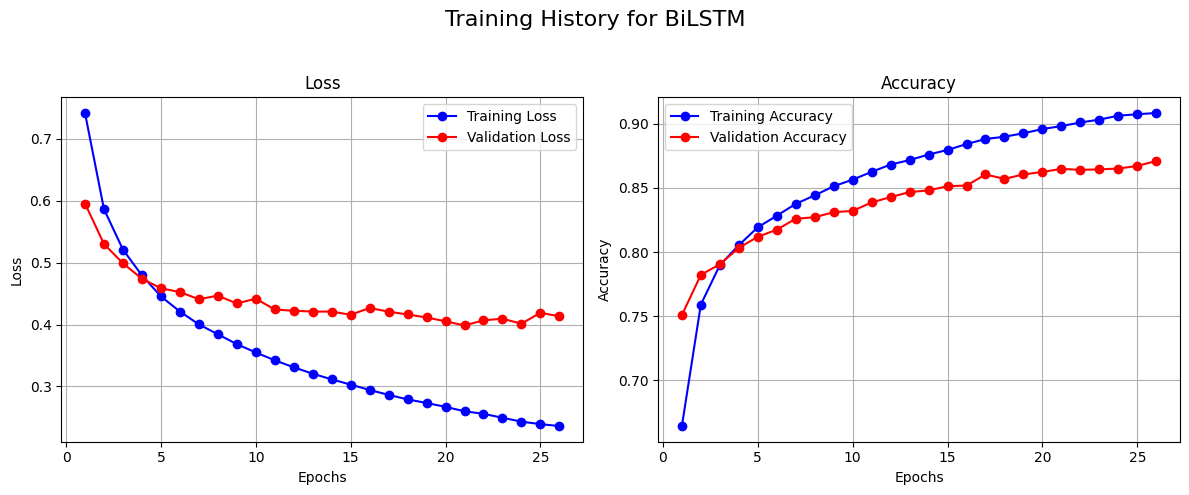

In [14]:
plot_training_history(history, model_name="BiLSTM")

In [15]:
# Kiểm tra độ chính xác của mô hình trên tập test
model.load_weights("/kaggle/working/model_bilstm.keras")
model.evaluate(X_test,y_test)

270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8224 - loss: 0.5931


[0.6229472756385803, 0.8204176425933838]

In [16]:
labels = ["neg","pos", "neu"]
y_pred = model.predict(X_test)  # Dự đoán trên tập test

y_pred = [labels[np.argmax(pred)] for pred in y_pred]
y_true = [labels[np.argmax(true)] for true in y_test]  # Nhãn thực tế trên tập test
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, zero_division=1)
print(report)

270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
              precision    recall  f1-score   support

         neg       0.81      0.85      0.83      2914
         neu       0.79      0.76      0.77      2903
         pos       0.88      0.85      0.86      2803

    accuracy                           0.82      8620
   macro avg       0.82      0.82      0.82      8620
weighted avg       0.82      0.82      0.82      8620



# **Xây dựng mô hình LSTM**

In [12]:
def generate_lstm_model():
  # khai báo ngưỡng dropout, đại diện cho tỷ lệ các đơn vị bị bỏ qua
  # trong quá trình huấn luyện để tránh việc_

  # gán kích thước của từ điển từ dữ liệu cho biến input_dim
  input_dim = data_vocab_size

  # gán kích thước đầu ra của lớp nhúng (embedding) cho biến output_dim.
  # Trong trường hợp này, các từ sẽ được biểu diễn bằng một vector 32 chiều.
  output_dim = 128

  # gán độ dài đầu vào cho biến input_length. đảm bảo rằng độ dài của các chuỗi
  # đầu vào sẽ được đệm (padding) hoặc cắt (truncation) để có cùng kích thước
  input_length = 40

  # khởi tạo một đối tượng GlorotNormal từ module initializers trong
  # thư viện Keras để sử dụng làm trình khởi tạo trọng số cho mạng nơ-ron.
  initializer = tf.keras.initializers.GlorotNormal()

  # khai báo lớp đầu vào với kích thước đầu vào là input_length
  input_layer = Input(shape=(input_length,))

  # thực hiện lớp nhúng (embedding) ánh xạ các từ sang các vector dựa trên
  # input_dim và output_dim. embeddings_initializer được sử dụng để khởi tạo
  # ma trận trọng số của lớp nhúng
  feature = Embedding(input_dim=input_dim, output_dim=output_dim,
                      input_length=input_length,
                      embeddings_initializer="GlorotNormal")(input_layer)

  lstm_feature = LSTM(units=128, return_sequences=True)(feature)
  lstm_feature = Dropout(0.3)(lstm_feature)
  lstm_feature = LSTM(units=64)(lstm_feature)


  classifier = Dense(50, activation = 'relu')(lstm_feature)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(30, activation = 'relu')(classifier)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(3, activation = 'softmax')(classifier)

  model = tf.keras.Model(inputs = input_layer, outputs= classifier)

  return model

model_lstm = generate_lstm_model()
adam = Adam(learning_rate=0.001)
model_lstm.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1748058905.896133      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 40)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 40, 128)             │       1,215,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 40, 128)             │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 40, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │           3,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           1,530 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              93 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,401,353 (5.35 MB)

 Trainable params: 1,401,353 (5.35 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Huấn luyện mô hình máy học sử dụng mạng CNN-BiLSTM trên dữ liệu huấn luyện và dữ liệu kiểm tra (validation)
#ModelCheckpoint nhằm lưu lại mô hình tại thời điểm có giá trị mất mát trên tập validation thấp nhất
callback_model = tf.keras.callbacks.ModelCheckpoint('/kaggle/working/model_lstm.keras', monitor='val_loss')
#Khai báo sử dụng call back để lưu mô hình tốt nhất, epoch là số lần mà toàn bộ tập dữ liệu huấn luyện được truyền qua mô hình
#Batchsize là số lượng mẫu dữ liệu được xử lý trước khi mô hình cập nhật trọng số
history = model_lstm.fit(x = X_train, y = y_train, validation_data = (X_val, y_val), epochs = 70, batch_size = 64, callbacks=[callback_model,early_stop])

Epoch 1/70


I0000 00:00:1748058915.363205     107 cuda_dnn.cc:529] Loaded cuDNN version 90300


1213/1213 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.3611 - loss: 1.0873 - val_accuracy: 0.4527 - val_loss: 1.0401
Epoch 2/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4579 - loss: 1.0399 - val_accuracy: 0.4498 - val_loss: 1.0438
Epoch 3/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4528 - loss: 1.0404 - val_accuracy: 0.4509 - val_loss: 1.0402
Epoch 4/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4576 - loss: 1.0367 - val_accuracy: 0.4287 - val_loss: 1.0438
Epoch 5/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4577 - loss: 1.0360 - val_accuracy: 0.4534 - val_loss: 1.0393
Epoch 6/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4608 - loss: 1.0353 - val_accuracy: 0.4559 - val_loss: 1.0373
Epoch 7/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4577 - loss: 1.0346 - val_accuracy: 0.4498 - val_loss: 1.0405
Epoch 8/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4567 - loss: 1.03

In [ ]:
# Kiểm tra độ chính xác của mô hình trên tập test
model_lstm.load_weights("/kaggle/working/model_lstm.keras")
model_lstm.evaluate(X_test,y_test)

539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7999 - loss: 0.6135


[0.6358428001403809, 0.7944895625114441]

In [ ]:
labels = ["neg","pos", "neu"]
y_pred = model_lstm.predict(X_test)  # Dự đoán trên tập test

y_pred = [labels[np.argmax(pred)] for pred in y_pred]
y_true = [labels[np.argmax(true)] for true in y_test]  # Nhãn thực tế trên tập test
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, zero_division=1)
print(report)

539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

         neg       0.82      0.79      0.80      5832
         neu       0.71      0.76      0.73      5766
         pos       0.86      0.84      0.85      5642

    accuracy                           0.79     17240
   macro avg       0.80      0.79      0.80     17240
weighted avg       0.80      0.79      0.80     17240



# **Xây dựng mô hình BiGRU**

In [ ]:
def generate_model_bigru():
  # khai báo ngưỡng dropout, đại diện cho tỷ lệ các đơn vị bị bỏ qua
  # trong quá trình huấn luyện để tránh việc quá khớp (overfitting)
  dropout_threshold = 0.3

  # gán kích thước của từ điển từ dữ liệu cho biến input_dim
  input_dim = data_vocab_size

  # gán kích thước đầu ra của lớp nhúng (embedding) cho biến output_dim.
  # Trong trường hợp này, các từ sẽ được biểu diễn bằng một vector 32 chiều.
  output_dim = 128

  # gán độ dài đầu vào cho biến input_length. đảm bảo rằng độ dài của các chuỗi
  # đầu vào sẽ được đệm (padding) hoặc cắt (truncation) để có cùng kích thước
  input_length = 40

  # khởi tạo một đối tượng GlorotNormal từ module initializers trong
  # thư viện Keras để sử dụng làm trình khởi tạo trọng số cho mạng nơ-ron.
  initializer = tf.keras.initializers.GlorotNormal()

  # khai báo lớp đầu vào với kích thước đầu vào là input_length
  input_layer = Input(shape=(input_length,))

  # thực hiện lớp nhúng (embedding) ánh xạ các từ sang các vector dựa trên
  # input_dim và output_dim. embeddings_initializer được sử dụng để khởi tạo
  # ma trận trọng số của lớp nhúng
  feature = Embedding(input_dim=input_dim, output_dim=output_dim,
                      input_length=input_length,
                      embeddings_initializer="GlorotNormal")(input_layer)

  bi_lstm_feature = Bidirectional(GRU(units=64, dropout=dropout_threshold, return_sequences=True, kernel_initializer=initializer))(feature)
  bi_lstm_feature = Dropout(dropout_threshold)(bi_lstm_feature)
  bi_lstm_feature = Bidirectional(GRU(units=32, dropout=dropout_threshold, kernel_initializer=initializer))(bi_lstm_feature)

  # bi_lstm_feature = Flatten()(bi_lstm_feature)



  # chuỗi các lớp mạng nơ-ron tiếp theo để xử lý tập đặc trưng đã kết hợp.
  # Các lớp này thực hiện các phép biến đổi phi tuyến để tạo ra dự đoán cuối cùng.
  # classifier = Dense(90, activation = 'relu')(combine_feature)
  # classifier = Dropout(0.3)(classifier)
  # classifier = Dense(70, activation = 'relu')(classifier)
  # classifier = Dropout(0.3)(classifier)
  classifier = Dense(50, activation = 'relu')(bi_lstm_feature)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(30, activation = 'relu')(classifier)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(3, activation = 'softmax')(classifier)

  model = tf.keras.Model(inputs = input_layer, outputs= classifier)

  return model

model_bigru = generate_model_bigru()
adam = Adam(learning_rate=0.001)
model_bigru.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
model_bigru.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 40)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_1 (Embedding)              │ (None, 40, 128)             │       1,215,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 40, 128)             │          74,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 40, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          31,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │           3,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           1,530 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              93 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,325,961 (5.06 MB)

 Trainable params: 1,325,961 (5.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện mô hình máy học sử dụng mạng CNN-BiLSTM trên dữ liệu huấn luyện và dữ liệu kiểm tra (validation)
#ModelCheckpoint nhằm lưu lại mô hình tại thời điểm có giá trị mất mát trên tập validation thấp nhất
callback_model = tf.keras.callbacks.ModelCheckpoint('/kaggle/working/model_bigru.keras', monitor='val_loss')
#Khai báo sử dụng call back để lưu mô hình tốt nhất, epoch là số lần mà toàn bộ tập dữ liệu huấn luyện được truyền qua mô hình
#Batchsize là số lượng mẫu dữ liệu được xử lý trước khi mô hình cập nhật trọng số
history = model_bigru.fit(x = X_train, y = y_train, validation_data = (X_val, y_val), epochs = 70, batch_size = 64, callbacks=[callback_model,early_stop])

Epoch 1/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.5846 - loss: 0.8389 - val_accuracy: 0.7454 - val_loss: 0.5975
Epoch 2/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7555 - loss: 0.5945 - val_accuracy: 0.7791 - val_loss: 0.5300
Epoch 3/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.7908 - loss: 0.5210 - val_accuracy: 0.7952 - val_loss: 0.4939
Epoch 4/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8113 - loss: 0.4714 - val_accuracy: 0.8002 - val_loss: 0.4810
Epoch 5/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8210 - loss: 0.4435 - val_accuracy: 0.8090 - val_loss: 0.4587
Epoch 6/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8302 - loss: 0.4179 - val_accuracy: 0.8172 - val_loss: 0.4554
Epoch 7/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8381 - loss: 0.4008 - val_accuracy: 0.8241 - val_loss: 0.4439
Epoch 8/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.8466 -

In [ ]:
# Kiểm tra độ chính xác của mô hình trên tập test
model_bigru.load_weights("/kaggle/input/bigru/keras/default/1/model_bigru.keras")
model_bigru.evaluate(X_test,y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8243 - loss: 0.5751


[0.6188316345214844, 0.8177494406700134]

In [ ]:
labels = ["neg","pos", "neu"]
y_pred = model_bigru.predict(X_test)  # Dự đoán trên tập test

y_pred = [labels[np.argmax(pred)] for pred in y_pred]
y_true = [labels[np.argmax(true)] for true in y_test]  # Nhãn thực tế trên tập test
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, zero_division=1)
print(report)

270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

         neg       0.82      0.85      0.83      2914
         neu       0.78      0.77      0.77      2903
         pos       0.87      0.85      0.86      2803

    accuracy                           0.82      8620
   macro avg       0.82      0.82      0.82      8620
weighted avg       0.82      0.82      0.82      8620



# **Xây dựng mô hình GRU**

In [ ]:
def generate_gru_model():
  # khai báo ngưỡng dropout, đại diện cho tỷ lệ các đơn vị bị bỏ qua
  # trong quá trình huấn luyện để tránh việc_

  # gán kích thước của từ điển từ dữ liệu cho biến input_dim
  input_dim = data_vocab_size

  # gán kích thước đầu ra của lớp nhúng (embedding) cho biến output_dim.
  # Trong trường hợp này, các từ sẽ được biểu diễn bằng một vector 32 chiều.
  output_dim = 128

  # gán độ dài đầu vào cho biến input_length. đảm bảo rằng độ dài của các chuỗi
  # đầu vào sẽ được đệm (padding) hoặc cắt (truncation) để có cùng kích thước
  input_length = 40

  # khởi tạo một đối tượng GlorotNormal từ module initializers trong
  # thư viện Keras để sử dụng làm trình khởi tạo trọng số cho mạng nơ-ron.
  initializer = tf.keras.initializers.GlorotNormal()

  # khai báo lớp đầu vào với kích thước đầu vào là input_length
  input_layer = Input(shape=(input_length,))

  # thực hiện lớp nhúng (embedding) ánh xạ các từ sang các vector dựa trên
  # input_dim và output_dim. embeddings_initializer được sử dụng để khởi tạo
  # ma trận trọng số của lớp nhúng
  feature = Embedding(input_dim=input_dim, output_dim=output_dim,
                      input_length=input_length,
                      embeddings_initializer="GlorotNormal")(input_layer)

  lstm_feature = GRU(units=128, return_sequences=True)(feature)
  lstm_feature = Dropout(0.3)(lstm_feature)
  lstm_feature = GRU(units=64)(lstm_feature)


  classifier = Dense(50, activation = 'relu')(lstm_feature)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(30, activation = 'relu')(classifier)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(3, activation = 'softmax')(classifier)

  model = tf.keras.Model(inputs = input_layer, outputs= classifier)

  return model

model_gru = generate_gru_model()
adam = Adam(learning_rate=0.001)
model_gru.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
model_gru.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 40)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 40, 128)             │       1,215,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 40, 128)             │          99,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 40, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 64)                  │          37,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │           3,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           1,530 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              93 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,356,681 (5.18 MB)

 Trainable params: 1,356,681 (5.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện mô hình máy học sử dụng mạng CNN-BiLSTM trên dữ liệu huấn luyện và dữ liệu kiểm tra (validation)
#ModelCheckpoint nhằm lưu lại mô hình tại thời điểm có giá trị mất mát trên tập validation thấp nhất
callback_model = tf.keras.callbacks.ModelCheckpoint('/kaggle/working/model_gru.keras', monitor='val_loss')
#Khai báo sử dụng call back để lưu mô hình tốt nhất, epoch là số lần mà toàn bộ tập dữ liệu huấn luyện được truyền qua mô hình
#Batchsize là số lượng mẫu dữ liệu được xử lý trước khi mô hình cập nhật trọng số
history = model_gru.fit(x = X_train, y = y_train, validation_data = (X_val, y_val), epochs = 70, batch_size = 64, callbacks=[callback_model,early_stop])

Epoch 1/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.3340 - loss: 1.0993 - val_accuracy: 0.3273 - val_loss: 1.0986
Epoch 2/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4476 - loss: 0.9775 - val_accuracy: 0.7320 - val_loss: 0.6207
Epoch 3/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7422 - loss: 0.6220 - val_accuracy: 0.7767 - val_loss: 0.5406
Epoch 4/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7904 - loss: 0.5159 - val_accuracy: 0.7986 - val_loss: 0.4825
Epoch 5/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8223 - loss: 0.4481 - val_accuracy: 0.8102 - val_loss: 0.4620
Epoch 6/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8392 - loss: 0.3983 - val_accuracy: 0.8263 - val_loss: 0.4273
Epoch 7/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8576 - loss: 0.3598 - val_accuracy: 0.8336 - val_loss: 0.4183
Epoch 8/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8682 -

In [ ]:
# Kiểm tra độ chính xác của mô hình trên tập test
model_gru.load_weights("/kaggle/working/model_gru.keras")
model_gru.evaluate(X_test,y_test)

270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8249 - loss: 0.6192


[0.6690046787261963, 0.8209976553916931]

In [ ]:
labels = ["neg","pos", "neu"]
y_pred = model_gru.predict(X_test)  # Dự đoán trên tập test

y_pred = [labels[np.argmax(pred)] for pred in y_pred]
y_true = [labels[np.argmax(true)] for true in y_test]  # Nhãn thực tế trên tập test
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, zero_division=1)
print(report)

270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

         neg       0.82      0.82      0.82      2914
         neu       0.76      0.78      0.77      2903
         pos       0.88      0.86      0.87      2803

    accuracy                           0.82      8620
   macro avg       0.82      0.82      0.82      8620
weighted avg       0.82      0.82      0.82      8620



# **Xây dựng mô hình CNN-BiLSTM**

In [12]:
def generate_bilstm_cnn_model():
  # khai báo ngưỡng dropout, đại diện cho tỷ lệ các đơn vị bị bỏ qua
  # trong quá trình huấn luyện để tránh việc quá khớp (overfitting)
  dropout_threshold = 0.3

  # gán kích thước của từ điển từ dữ liệu cho biến input_dim
  input_dim = data_vocab_size

  # gán kích thước đầu ra của lớp nhúng (embedding) cho biến output_dim.
  # Trong trường hợp này, các từ sẽ được biểu diễn bằng một vector 32 chiều.
  output_dim = 128

  # gán độ dài đầu vào cho biến input_length. đảm bảo rằng độ dài của các chuỗi
  # đầu vào sẽ được đệm (padding) hoặc cắt (truncation) để có cùng kích thước
  input_length = 100

  # khởi tạo một đối tượng GlorotNormal từ module initializers trong
  # thư viện Keras để sử dụng làm trình khởi tạo trọng số cho mạng nơ-ron.
  initializer = tf.keras.initializers.GlorotNormal()

  # khai báo lớp đầu vào với kích thước đầu vào là input_length
  input_layer = Input(shape=(input_length,))

  # thực hiện lớp nhúng (embedding) ánh xạ các từ sang các vector dựa trên
  # input_dim và output_dim. embeddings_initializer được sử dụng để khởi tạo
  # ma trận trọng số của lớp nhúng
  feature = Embedding(input_dim=input_dim, output_dim=output_dim,
                      input_length=input_length,
                      embeddings_initializer="GlorotNormal")(input_layer)

  cnn_feature = Conv1D(filters=64, kernel_size=3, padding='same',
                       activation='relu')(feature)
  avg = GlobalAveragePooling1D()(cnn_feature)
  max = GlobalMaxPooling1D()(cnn_feature)



#Kết hợp giữa LSTM hai chiều và GRU hai chiều, áp dụng thêm Dropout giữa các lớp, làm cho mô hình này phức tạp hơn và có khả năng giảm overfitting nhờ Dropout.
  bi_lstm_feature = Bidirectional(LSTM(units=64, dropout=dropout_threshold, kernel_initializer=initializer))(feature)


  # kết hợp hai tập đặc trưng từ các lớp tích chập và LSTM thành
  # một tập đặc trưng duy nhất bằng cách kết hợp chúng theo chiều thứ hai.
  combine_feature = tf.keras.layers.Concatenate()([avg, max])
  average = Average()([ bi_lstm_feature, combine_feature])


  # chuỗi các lớp mạng nơ-ron tiếp theo để xử lý tập đặc trưng đã kết hợp.
  # Các lớp này thực hiện các phép biến đổi phi tuyến để tạo ra dự đoán cuối cùng.
  classifier = Dense(90, activation = 'relu')(average)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(70, activation = 'relu')(classifier)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(50, activation = 'relu')(classifier)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(30, activation = 'relu')(classifier)
  classifier = Dropout(0.3)(classifier)
  classifier = Dense(3, activation = 'softmax')(classifier)

  model = tf.keras.Model(inputs = input_layer, outputs= classifier)

  return model

bilstm_cnn_model = generate_bilstm_cnn_model()
adam = Adam(learning_rate=0.001)
bilstm_cnn_model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
bilstm_cnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1748150380.893941      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 100)            │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 100, 128)       │      1,215,488 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 100, 64)        │         24,640 │ embedding[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d  │ (None, 64)             │              0 │ conv1d[0][0]           │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d      │ (None, 64)             │              0 │ conv1d[0][0]           │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 128)            │         98,816 │ embedding[0][0]        │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 128)            │              0 │ global_average_poolin… │
│                           │                        │                │ global_max_pooling1d[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ average (Average)         │ (None, 128)            │              0 │ bidirectional[0][0],   │
│                           │                        │                │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 90)             │         11,610 │ average[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 90)             │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 70)             │          6,370 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 70)             │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 50)             │          3,550 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 50)             │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 30)             │          1,530 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 30)             │              0 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 3)              │             93 │ dropout_3[0][0]        │
└──────────────────────

 Total params: 1,362,097 (5.20 MB)

 Trainable params: 1,362,097 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Huấn luyện mô hình máy học sử dụng mạng CNN-BiLSTM trên dữ liệu huấn luyện và dữ liệu kiểm tra (validation)
#ModelCheckpoint nhằm lưu lại mô hình tại thời điểm có giá trị mất mát trên tập validation thấp nhất
callback_model = tf.keras.callbacks.ModelCheckpoint('/kaggle/working/model_bilstm_cnn.keras', monitor='val_loss')
#Khai báo sử dụng call back để lưu mô hình tốt nhất, epoch là số lần mà toàn bộ tập dữ liệu huấn luyện được truyền qua mô hình
#Batchsize là số lượng mẫu dữ liệu được xử lý trước khi mô hình cập nhật trọng số
history = bilstm_cnn_model.fit(x = X_train, y = y_train, validation_data = (X_val, y_val), epochs = 70, batch_size = 64, callbacks=[callback_model,early_stop])

Epoch 1/70


I0000 00:00:1748150393.182193     101 cuda_dnn.cc:529] Loaded cuDNN version 90300


1213/1213 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.5861 - loss: 0.8374 - val_accuracy: 0.7647 - val_loss: 0.5590
Epoch 2/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.7816 - loss: 0.5484 - val_accuracy: 0.8170 - val_loss: 0.4579
Epoch 3/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.8316 - loss: 0.4388 - val_accuracy: 0.8400 - val_loss: 0.4102
Epoch 4/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.8656 - loss: 0.3538 - val_accuracy: 0.8551 - val_loss: 0.3811
Epoch 5/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.8880 - loss: 0.3016 - val_accuracy: 0.8640 - val_loss: 0.3750
Epoch 6/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.9013 - loss: 0.2652 - val_accuracy: 0.8715 - val_loss: 0.3815
Epoch 7/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.9122 - loss: 0.2393 - val_accuracy: 0.8802 - val_loss: 0.3630
Epoch 8/70
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.9212 - loss: 0.21

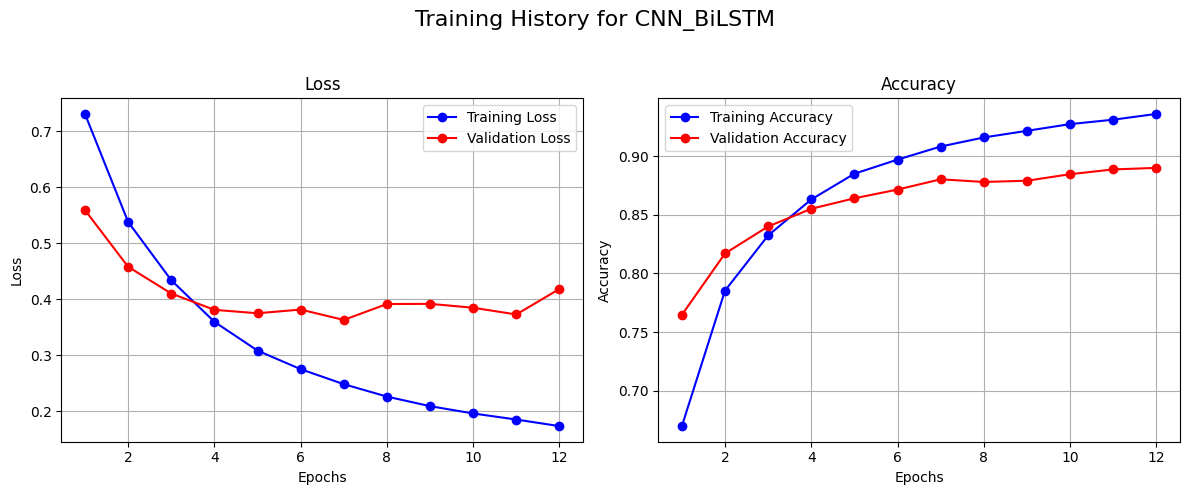

In [16]:
plot_training_history(history, model_name="CNN_BiLSTM")

In [14]:
# Kiểm tra độ chính xác của mô hình trên tập test
bilstm_cnn_model.load_weights("/kaggle/working/model_bilstm_cnn.keras")
bilstm_cnn_model.evaluate(X_test,y_test)

270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8338 - loss: 0.6656


[0.7080422043800354, 0.830394446849823]

In [15]:
labels = ["neg","pos", "neu"]
y_pred = bilstm_cnn_model.predict(X_test)  # Dự đoán trên tập test

y_pred = [labels[np.argmax(pred)] for pred in y_pred]
y_true = [labels[np.argmax(true)] for true in y_test]  # Nhãn thực tế trên tập test
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, zero_division=1)
print(report)

270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

         neg       0.82      0.87      0.84      2914
         neu       0.81      0.75      0.78      2903
         pos       0.86      0.88      0.87      2803

    accuracy                           0.83      8620
   macro avg       0.83      0.83      0.83      8620
weighted avg       0.83      0.83      0.83      8620

